In [88]:
SQLITE_PATH = './../data/dbfinal.sqlite3'
CSV_PATH = './../data/final_data_2/ml_final_data_test.csv'
MODEL_PATH = './../stored_models/model_6_multiple_losses_V3.h5'
ML_DATA_TEST_PATH = './../data/final_data_2/ml_final_data_test.csv'
import sqlite3
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.python.client import device_lib
import os
import sys
from collections import Counter
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input, BatchNormalization, Activation, Add, LeakyReLU, Concatenate, Multiply
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionResNetV2, VGG16, MobileNetV2
from tensorflow.keras.utils import to_categorical
import keras.backend as K
from PIL import Image
import requests
import zipfile

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output as cls
from keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
import pandas as pd
import PIL

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import statistics
import ast
import json
import statistics

import glob
import cv2
from PIL import Image
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

import chess

module_path = os.path.abspath(os.path.join('..', 'utils'))
if module_path not in sys.path:
    sys.path.append(module_path)

from utils2 import DataGenerator, plot_graph, bar_plot, two_bar_plot, StepwiseLogger, decode_pos

def execute_query(db, query):
    conn = sqlite3.connect(db)
    cur = conn.cursor()
    cur.execute(query)
    rows = cur.fetchall()
    conn.commit()
    conn.close()
    return rows

In [107]:
data = pd.DataFrame(execute_query(SQLITE_PATH, "SELECT * FROM moves;"))
data.rename(columns={0:'move', 1:'is_blunder_cp', 2:'board_pgn', 3:'is_check'}, inplace=True)

In [108]:
data

,move,is_blunder_cp,board_pgn,is_check
0,e2e4,0,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,0
1,g1f3,0,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,0
2,d2d4,0,rnbqkbnr/1ppp1ppp/p3p3/8/4P3/5N2/PPPP1PPP/RNBQ...,0
3,b2b3,0,rnbqkbnr/2pp1ppp/p3p3/1p6/3PP3/5N2/PPP2PPP/RNB...,0
4,f1d3,0,rn1qkbnr/1bpp1ppp/p3p3/1p6/3PP3/1P3N2/P1P2PPP/...,0
...,...,...,...,...
4828123,h7h8,0,2r2k2/p4ppQ/2p2b1p/3p4/q2P2Pn/P2BP2P/5P2/R1R3K...,0
4828124,h8c8,0,2r4Q/p3kpp1/2p2b1p/3p4/q2P2Pn/P2BP2P/5P2/R1R3K...,0
4828125,g1g2,0,2Q5/p3kpp1/2p2b1p/3p4/q2P2P1/P2BPn1P/5P2/R1R3K...,1
4828126,g2g3,1,2Q5/p3kpp1/2p2b1p/3p4/q2P2Pn/P2BP2P/5PK1/R1R5 ...,1


In [109]:
value_counts = data['move'].value_counts()

In [110]:
len(value_counts)

1859

In [111]:
bins = [0, 10, 100, 1000, 10000, 100000]
labels = ['0-10', '10-10\u00b2', '10\u00b2-10\N{SUPERSCRIPT THREE}', '10\N{SUPERSCRIPT THREE}-10\N{SUPERSCRIPT FOUR}', '+10\N{SUPERSCRIPT FOUR}']
frequency_bins = pd.cut(value_counts, bins=bins, labels=labels, right=True)
frequency_bins

move
g1f3      NaN
d2d4      NaN
e1g1      NaN
e2e4      NaN
b1c3      NaN
         ... 
e7d8b    0-10
g7f8b    0-10
g7f8n    0-10
a7b8n    0-10
b7a8r    0-10
Name: count, Length: 1859, dtype: category
Categories (5, object): ['0-10' < '10-10²' < '10²-10³' < '10³-10⁴' < '+10⁴']

In [112]:
frequency_bin_counts = frequency_bins.value_counts().sort_index()
frequency_bin_counts

count
0-10         36
10-10²      104
10²-10³    1062
10³-10⁴     557
+10⁴         95
Name: count, dtype: int64

<Axes: xlabel='move'>

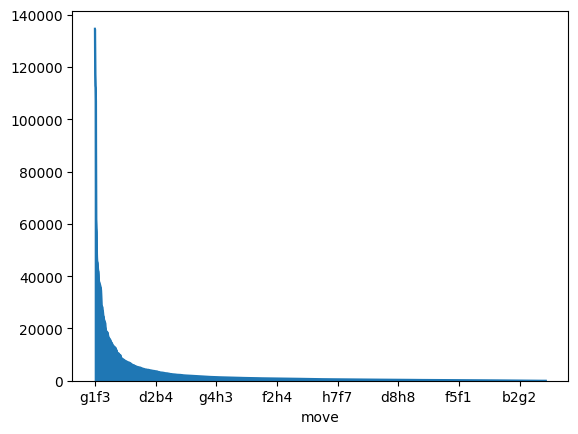

In [113]:
value_counts.plot(kind='area')

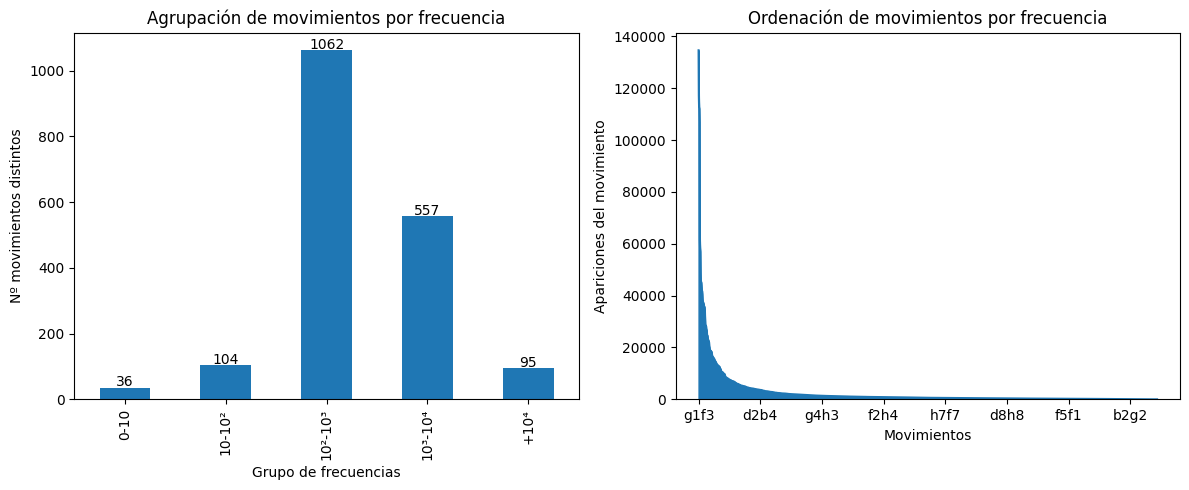

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bar_plot = frequency_bin_counts.plot(kind='bar', ax=axes[0])
axes[0].set_xlabel('Grupo de frecuencias')
axes[0].set_ylabel('Nº movimientos distintos')
axes[0].set_title('Agrupación de movimientos por frecuencia')

value_counts.plot(kind='area', ax=axes[1])
axes[1].set_xlabel('Movimientos')
axes[1].set_ylabel('Apariciones del movimiento')
axes[1].set_title('Ordenación de movimientos por frecuencia')
axes[1].set_yscale('linear')

for bar in bar_plot.patches:
    bar_plot.annotate(format(bar.get_height(), '.0f'),
                      (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                      ha='center', va='center', xytext=(0, 4),
                      textcoords='offset points')
    
plt.tight_layout()
plt.show()

In [115]:
moves_needed = 0
total = 0 
for value in value_counts:
    moves_needed += 1
    total += value
    if total >= sum(value_counts)*50/100:
        print(moves_needed)
        break

73


In [116]:
sum(value_counts)

4828128

In [117]:
value_counts.median()

607.0

In [118]:
sum(value_counts[:5])

583579

In [119]:
is_blunder_value_counts = data['is_blunder_cp'].value_counts()
is_blunder_value_counts

is_blunder_cp
0    4318913
1     509215
Name: count, dtype: int64

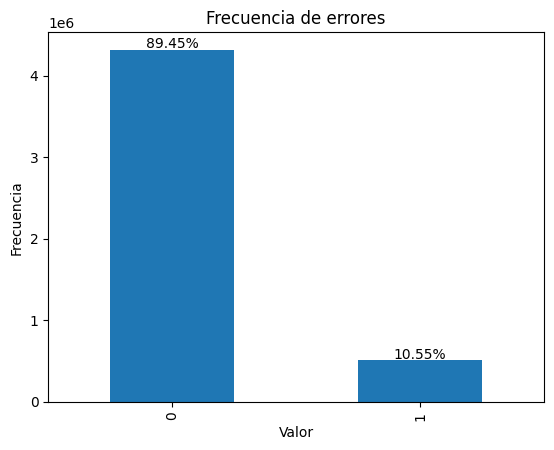

In [134]:
bar_plot = is_blunder_value_counts.plot(kind='bar')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.title('Frecuencia de errores')

for bar in bar_plot.patches:
    bar_plot.annotate(format((bar.get_height()/len(data))*100, '.2f') + '%',
                      (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                      ha='center', va='center', xytext=(0, 4),
                      textcoords='offset points')

In [136]:
data2 = pd.read_csv(CSV_PATH)

In [169]:
initial_value_counts = data2['initial_pos'].value_counts()
initial_value_counts

initial_pos
f1    27655
e2    26127
d2    25898
g1    23673
d1    21375
      ...  
c8      706
b8      634
h8      630
f8      567
g8      437
Name: count, Length: 64, dtype: int64

In [176]:
def bar_plot(x, y, title, xlabel, ylabel):
    plt.figure(figsize=(15, 6))
    plt.bar(x, y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(x, [f'{i}' for i in x])
    plt.tight_layout()
    plt.show()

In [171]:
def sort_value_counts(value_counts):
    sorted_value_counts = []
    values = []
    for row in ['8','7','6','5','4','3','2','1']:
        for column in ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']:
            values.append(column+row)
            sorted_value_counts.append(value_counts[column + row])
    return values, sorted_value_counts

In [173]:
values, sorted_value_counts = sort_value_counts(initial_value_counts)

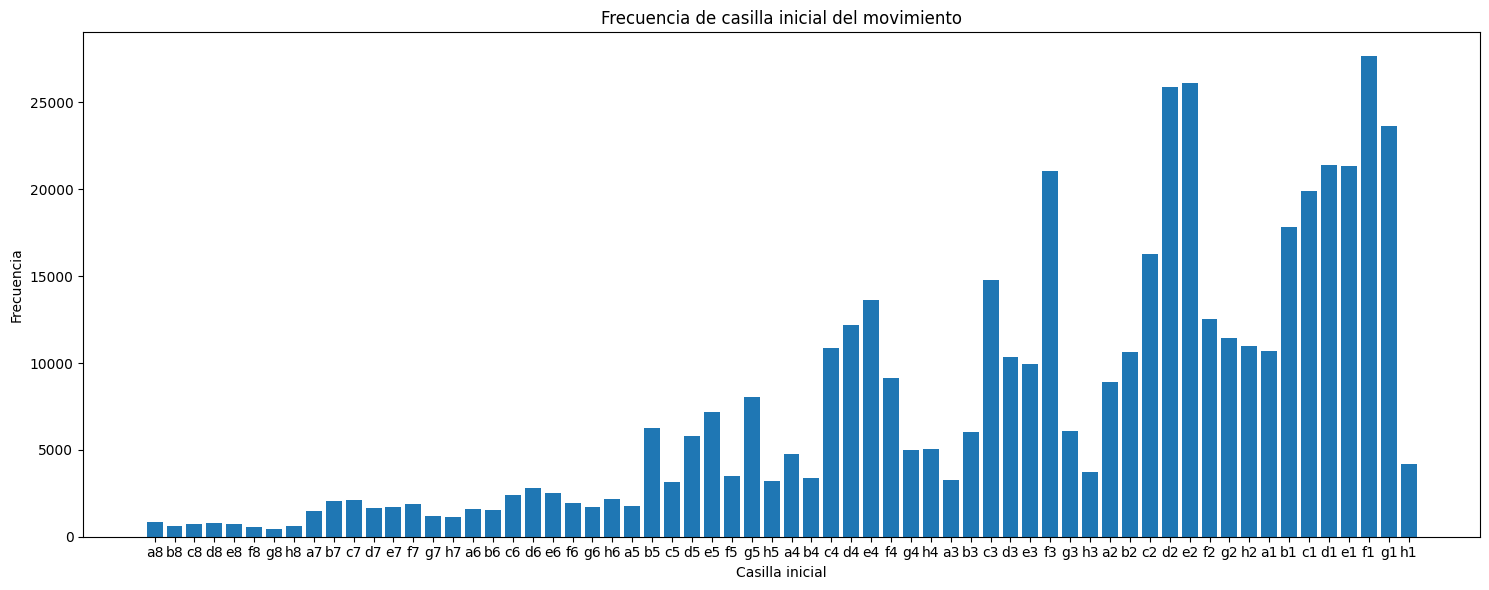

In [177]:
bar_plot(values, sorted_value_counts, "Frecuencia de casilla inicial del movimiento", "Casilla inicial", "Frecuencia")

In [181]:
final_value_counts = data2['final_pos'].value_counts()
values, sorted_value_counts = sort_value_counts(final_value_counts)

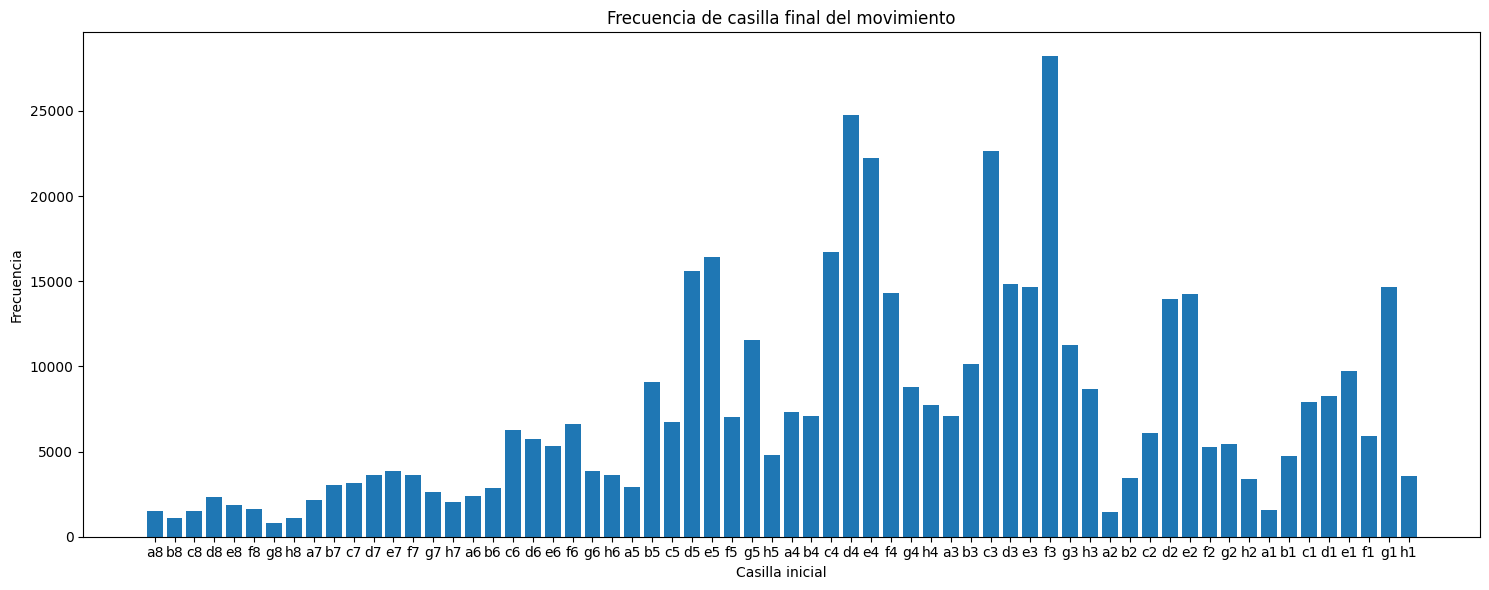

In [182]:
bar_plot(values, sorted_value_counts, "Frecuencia de casilla final del movimiento", "Casilla inicial", "Frecuencia")

## Evaluación de modelo final

In [3]:
model = load_model(MODEL_PATH)

In [4]:
read_size = 524288
batch_size = 64
num_classes = 64
test_data_generator = DataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, num_classes, 482813, single_and_partial=True, shuffle=False)

In [3]:
model.evaluate(test_data_generator)
test_data_generator.current_read = None

7544/7544 [==============================] - 84s 9ms/step - loss: 4.6391 - full_move_loss: 1.8448 - initial_pos_loss: 1.1902 - final_pos_loss: 1.6041 - full_move_accuracy: 0.4536 - initial_pos_accuracy: 0.5726 - final_pos_accuracy: 0.4877


In [5]:
moves_preds = []
initial_pos_preds = []
final_pos_preds = []
for i in range(0, test_data_generator.__len__()):
    result = model.predict_on_batch(test_data_generator.__getitem__(i)[0])
    for j in range(len(result[0])):
        moves_preds.append(np.argmax(result[0][j]))
        initial_pos_preds.append(np.argmax(result[1][j]))
        final_pos_preds.append(np.argmax(result[2][j]))
test_data_generator.current_read = None

In [6]:
moves_preds = np.array(moves_preds)
initial_pos_preds = np.array(initial_pos_preds)
final_pos_preds = np.array(final_pos_preds)

In [8]:
np.argmax(test_data_generator.encode_single_move(['b8a8']))

64

In [11]:
def decode_moves(moves):
    number_to_column = {
        1 : 'a',
        2 : 'b',
        3 : 'c',
        4 : 'd',
        5 : 'e',
        6 : 'f',
        7 : 'g',
        8 : 'h'
    }
    decoded_moves = []
    for move in moves:
        final_column = number_to_column.get(move % 8 + 1)
        final_row = str(8 - (move // 8) % 8)
        initial_column = number_to_column.get((move // 64) % 8 + 1)
        initial_row = str(8 - (move // 512) % 8)
        decoded_moves.append(initial_column + initial_row + final_column + final_row)
    return decoded_moves

In [10]:
np.argmax(test_data_generator.encode_single_move(decode_moves([64])))

64

In [8]:
test_df = pd.read_csv(ML_DATA_TEST_PATH)

In [87]:
print(classification_report(test_df['move'], decode_moves(moves_preds), digits=4))

c:\Users\Usuario\anaconda3\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Usuario\anaconda3\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        a1a2     0.5187    0.3079    0.3865       315
        a1a3     0.4632    0.2558    0.3296       172
        a1a4     0.5038    0.4615    0.4818       143
        a1a5     0.5200    0.4333    0.4727       120
        a1a6     0.4368    0.5724    0.4955       145
        a1a7     0.4163    0.5573    0.4766       192
        a1a8     0.5000    0.4607    0.4795       178
        a1b1     0.3962    0.2694    0.3207      1841
        a1b2     0.4510    0.3898    0.4182        59
        a1b3     0.3846    0.6250    0.4762         8
        a1c1     0.3835    0.2895    0.3300      2473
        a1c2     0.4444    0.4000    0.4211        10
        a1c3     0.6875    0.3929    0.5000        28
        a1d1     0.4089    0.4206    0.4147      2487
        a1d4     0.2941    0.2941    0.2941        17
        a1e1     0.4304    0.4000    0.4146      1460
        a1e5     0.4444    0.2857    0.3478        14
        a1f1     0.4801    

c:\Users\Usuario\anaconda3\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
f1_score(test_df['move'],  decode_moves(moves_preds), average='weighted')

0.4435585088361775

In [12]:
f1_scores = f1_score(test_df['move'], decode_moves(moves_preds), average=None)

In [16]:
f1_series = pd.Series(f1_scores)
f1_series.describe()

count    1792.000000
mean        0.364750
std         0.137179
min         0.000000
25%         0.285714
50%         0.380401
75%         0.453681
max         0.793388
dtype: float64

In [21]:
f1_series.value_counts().sort_index()

0.000000    56
0.048780     1
0.051282     1
0.058824     1
0.060606     2
            ..
0.745186     1
0.763848     1
0.766917     1
0.790721     1
0.793388     1
Name: count, Length: 1182, dtype: int64

In [74]:
test_df['move'].value_counts()

move
g1f3    13461
d2d4    11715
e1g1    11277
e2e4    11211
b1c3    10694
        ...  
a1h8        2
b7h1        2
h1b7        2
c6h1        2
h1a8        1
Name: count, Length: 1792, dtype: int64

In [82]:
matrix = confusion_matrix(test_df['move'], decode_moves(moves_preds))
recall_scores = matrix.diagonal()/matrix.sum(axis=0)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20244\3962450176.py:2: RuntimeWarning: invalid value encountered in divide
  recall_scores = matrix.diagonal()/matrix.sum(axis=0)


In [83]:
accuracy_series = pd.Series(recall_scores)
accuracy_series.describe()

count    1773.000000
mean        0.380108
std         0.133197
min         0.000000
25%         0.312120
50%         0.382479
75%         0.457584
max         1.000000
dtype: float64

In [51]:
accuracy_series.value_counts().sort_index(ascending=False)

0.950000     1
0.906977     1
0.905660     1
0.903448     1
0.888889     1
            ..
0.045455     1
0.043478     1
0.041667     1
0.037037     2
0.000000    56
Name: count, Length: 1078, dtype: int64

In [55]:
precision_scores = precision_score(test_df['move'], decode_moves(moves_preds), average=None)

c:\Users\Usuario\anaconda3\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [54]:
precision_scores = pd.Series(precision_scores)
precision_scores.describe()

count    1792.000000
mean        0.376078
std         0.138093
min         0.000000
25%         0.308301
50%         0.381070
75%         0.456771
max         1.000000
dtype: float64

In [89]:
recall_scores =recall_score(test_df['move'], decode_moves(moves_preds), average=None)

In [90]:
recall_scores = pd.Series(recall_scores)
recall_scores.describe()

count    1792.000000
mean        0.379477
std         0.171391
min         0.000000
25%         0.263158
50%         0.384615
75%         0.500000
max         0.950000
dtype: float64

## Jugadas validas

In [22]:
def calculate_valid_moves(initial_pos_preds, final_pos_preds, moves_preds, df):
    valid_init_pos = 0
    valid_final_pos = 0
    valid_moves = 0
    for index, row in df.iterrows():
        if(index % 10000 == 0):
            display(index, clear=True)
        board = chess.Board(row['board_pgn'])
        init_pos_predicted = initial_pos_preds[index]
        final_pos_predicted = final_pos_preds[index]
        init_pos_is_legal = init_pos_predicted in [move.uci()[:2] for move in board.legal_moves]
        final_pos_is_legal = final_pos_predicted in [move.uci()[2:4] for move in board.legal_moves]
        move_is_legal = moves_preds[index] in [move.uci()[:4] for move in board.legal_moves]

        if init_pos_is_legal:
            valid_init_pos += 1
        if final_pos_is_legal:
            valid_final_pos += 1
        if move_is_legal:
            valid_moves += 1
    
    return valid_init_pos, valid_final_pos, valid_moves

In [23]:
valid_init_pos, valid_final_pos, valid_moves = calculate_valid_moves(decode_pos(initial_pos_preds), decode_pos(final_pos_preds), decode_moves(moves_preds), test_df)

480000

In [26]:
print(f"Legal Initial Positions: {valid_init_pos}, {round(valid_init_pos/len(moves_preds)*100,3)}%\nLegal Final Positions: {valid_final_pos}, {round(valid_final_pos/len(moves_preds)*100, 3)}%\nLegal Moves: {valid_moves}, {round(valid_moves/len(moves_preds)*100, 3)}%")

Legal Initial Positions: 481332, 99.693%
Legal Final Positions: 480176, 99.454%
Legal Moves: 479085, 99.228%


## Accuracy del movimiento

In [37]:
test_df['move'][0:10]

0    b5b6
1    e2e4
2    e2e4
3    b5d7
4    e2e4
5    b2f6
6    d1d4
7    e1g1
8    d4e5
9    c4b3
Name: move, dtype: object

In [40]:
def get_move_acc(moves_preds, df):
    correct_moves = 0
    correct_blunders = 0
    correct_checks = 0
    for index, row in df.iterrows():
        if decode_moves([moves_preds[index]])[0] == row['move']:
            correct_moves += 1
            if row['is_blunder_cp'] == 1:
                correct_blunders += 1
            if row['is_check'] == 1:
                correct_checks += 1
            
    return correct_moves, correct_blunders, correct_checks

In [42]:
correct_moves, correct_blunders, correct_checks = get_move_acc(moves_preds, test_df)

In [43]:
print(str(round(correct_moves/len(test_df)*100, 3)) + '%')
print(str(round(correct_blunders/test_df['is_blunder_cp'].sum()*100, 3)) + '%')
print(str(round(correct_checks/test_df['is_check'].sum()*100, 3)) + '%')

45.358%
27.455%
62.933%


In [92]:
test_df['is_blunder_cp'].sum()/len(test_df)

0.10560196183615603

In [44]:
len(test_df)

482813